# **IMPORT LIBRARY**

In [1]:
import os
import glob
import os.path as osp
import csv
import mmengine
import copy as cp
import matplotlib.pyplot as plt
import pickle

from collections import Counter

## PATH FOLDER

In [17]:
PKL_DIR       = '../ver2026/03_dataset/0_data_baru/_ekstraksi_skeleton/_data_in_baru/2_csv'
pickles_path  = '../ver2026/03_dataset/data_in/to-combine-new2'
label_map_dir = '../ver2026/03_dataset/ciis_label_map.txt'

# rasio train-validation split
split_ratio   = 0

# cek file pkl yang sudah di combine
combined_pkl  = '../ver2026/03_dataset/data_train/fin_new/ciis_26_v3.pkl'
test_pkl = '../ver2026/03_dataset/data_train/fin_new/ciis_26_test1x.pkl'

## LOAD LABEL MAP

In [11]:
def load_label_map(file_path):
    label_to_id = {}
    id_to_label = {}

    with open(file_path) as f:
        for line in f:
            if ":" in line:
                label, aksi = line.strip().split(":")
                label = int(label.strip())
                aksi = aksi.strip()

                label_to_id[aksi] = label
                id_to_label[label] = aksi

    return label_to_id, id_to_label

stdet_label_map, _ = load_label_map(label_map_dir)
stdet_label_map

{'normal': 0,
 'berjongkok': 1,
 'merayap': 2,
 'membidik senapan': 3,
 'membidik pistol': 4,
 'memukul': 5,
 'menendang': 6}

## LABELING VIDEO

In [21]:
csv_files = sorted(glob.glob(osp.join(PKL_DIR, '**', '*.csv'), recursive=True))

print(f'Total CSV ditemukan: {len(csv_files)}')
print()

sukses = 0
skip   = 0
gagal  = 0

for csv_path in csv_files:
    base     = osp.splitext(csv_path)[0]
    pkl_path = base + '.pkl'
    nama     = osp.basename(csv_path)

    # Cek PKL mentah
    if not osp.exists(pkl_path):
        print(f'  ⏭  SKIP  — PKL tidak ditemukan : {csv_path}')
        skip += 1
        continue

    # Baca CSV
    custom_annos = []
    with open(csv_path, newline='') as f:
        for row in csv.reader(f):
            if not row or row[0].strip() in ('none', 'annotate!', ''):
                continue
            label_name = row[0].strip()
            csv_id     = float(row[1].strip())
            if label_name in stdet_label_map:
                custom_annos.append((label_name, csv_id))

    if not custom_annos:
        print(f'  ⏭  SKIP  — Tidak ada anotasi  : {nama}')
        skip += 1
        continue

    # Load PKL mentah + assign label
    try:
        skeleton_data  = mmengine.load(pkl_path)
        custom_dataset = []

        for ann in custom_annos:
            label_name, csv_id_target = ann
            for data in skeleton_data:
                if abs(data.get('csv_id', -1) - csv_id_target) < 1e-6:
                    labeled          = data.copy()
                    labeled['label'] = stdet_label_map[label_name]
                    custom_dataset.append(labeled)
                    break

        if not custom_dataset:
            print(f'  ⏭  SKIP  — Tidak ada clip cocok : {nama}')
            skip += 1
            continue

        # Simpan ke to-combine
        os.makedirs(pickles_path, exist_ok=True)
        nama_file = 'labeled_' + os.path.basename(base) + '.pkl'
        out_path  = os.path.join(pickles_path, nama_file)
        mmengine.dump(custom_dataset, out_path)

        #print(f'  ✓  OK    — {nama:40s} → {len(custom_dataset)} clip berlabel')
        sukses += 1

    except Exception as e:
        print(f'  ✗  GAGAL — {nama:40s} → ERROR: {e}')
        gagal += 1
        continue

print(f'\n{"="*55}')
print(f'SELESAI')
print(f'  ✓  Berhasil : {sukses} file')
print(f'  ⏭  Di-skip  : {skip} file')
print(f'  ✗  Gagal    : {gagal} file')
print(f'{"="*55}')

Total CSV ditemukan: 89

  ⏭  SKIP  — Tidak ada anotasi  : lab_6_12FPS_bagian022.csv
  ⏭  SKIP  — Tidak ada anotasi  : lab_6_12FPS_bagian023.csv
  ⏭  SKIP  — Tidak ada anotasi  : h23_1_6FPS_bagian009.csv
  ⏭  SKIP  — Tidak ada anotasi  : Top 60 Crazy Knockouts 2023 in Kickboxing & Muay Thai_bagian076.csv
  ⏭  SKIP  — Tidak ada anotasi  : 0Ow4cotKOuw_2.csv
  ⏭  SKIP  — Tidak ada anotasi  : 0Ow4cotKOuw_3.csv
  ⏭  SKIP  — Tidak ada anotasi  : JECBfnp2ZXc_1.csv
  ⏭  SKIP  — Tidak ada anotasi  : mwuiYEBdkJs_1.csv
  ⏭  SKIP  — Tidak ada anotasi  : 9kly-mpQczg_0.csv
  ⏭  SKIP  — Tidak ada anotasi  : v4dhdnsxiX4_1.csv

SELESAI
  ✓  Berhasil : 79 file
  ⏭  Di-skip  : 10 file
  ✗  Gagal    : 0 file


## COMBINE PKL

In [22]:
custom_datasets = dict(
    split=dict(xsub_train=[], xsub_val=[], xview_train=[], xview_val=[]),
    annotations=[]
)

for file_path in glob.glob(os.path.join(pickles_path, '**', '*.pkl'), recursive=True):
    #print(os.path.basename(file_path))
    ds = mmengine.load(file_path)
    for i, data in enumerate(ds):
        custom_datasets['annotations'].append(data)
        split_key = 'train' if (i % 10) < (split_ratio * 10) else 'val'
        custom_datasets['split'][f'xsub_{split_key}'].append(data['frame_dir'])
        custom_datasets['split'][f'xview_{split_key}'].append(data['frame_dir'])

mmengine.dump(custom_datasets, combined_pkl)
n_tr = len(custom_datasets['split']['xsub_train'])
n_va = len(custom_datasets['split']['xsub_val'])
print(f'\nCombined PKL: {combined_pkl}')
print(f'Train: {n_tr} | Val: {n_va} | Total: {n_tr + n_va}')


Combined PKL: ../ver2026/03_dataset/data_train/fin_new/ciis_26_test2.pkl
Train: 0 | Val: 1463 | Total: 1463


## **DISTRIBUSI CLIP PER KELAS**

In [18]:
# INFO PKL
path = combined_pkl

data_pkl = mmengine.load(path)

# Hitung label per kelas
labels = [ann['label'] for ann in data_pkl['annotations']]
counter = Counter(labels)

_, stdet_label_map_id = load_label_map(label_map_dir)

# Load label map untuk nama kelas
print(f'Total clip: {len(labels)}')
print(f'Total kelas: {len(counter)}')
print()
print(f'{"ID":>3} | {"Kelas":<20} | {"Jumlah":>7} | Proporsi')
print('-' * 100)

for label_id, count in sorted(counter.items()):
    nama      = stdet_label_map_id.get(label_id, f'kelas_{label_id}')
    propoorsi = count / len(labels) * 100
    bar       = '█' * (count // 10)
    print(f'{label_id:>3} | {nama:<20} | {count:>7} | {propoorsi:6.2f}% {bar}')

Total clip: 3072
Total kelas: 7

 ID | Kelas                |  Jumlah | Proporsi
----------------------------------------------------------------------------------------------------
  0 | normal               |     495 |  16.11% █████████████████████████████████████████████████
  1 | berjongkok           |     469 |  15.27% ██████████████████████████████████████████████
  2 | merayap              |     493 |  16.05% █████████████████████████████████████████████████
  3 | membidik senapan     |     509 |  16.57% ██████████████████████████████████████████████████
  4 | membidik pistol      |     493 |  16.05% █████████████████████████████████████████████████
  5 | memukul              |     315 |  10.25% ███████████████████████████████
  6 | menendang            |     298 |   9.70% █████████████████████████████


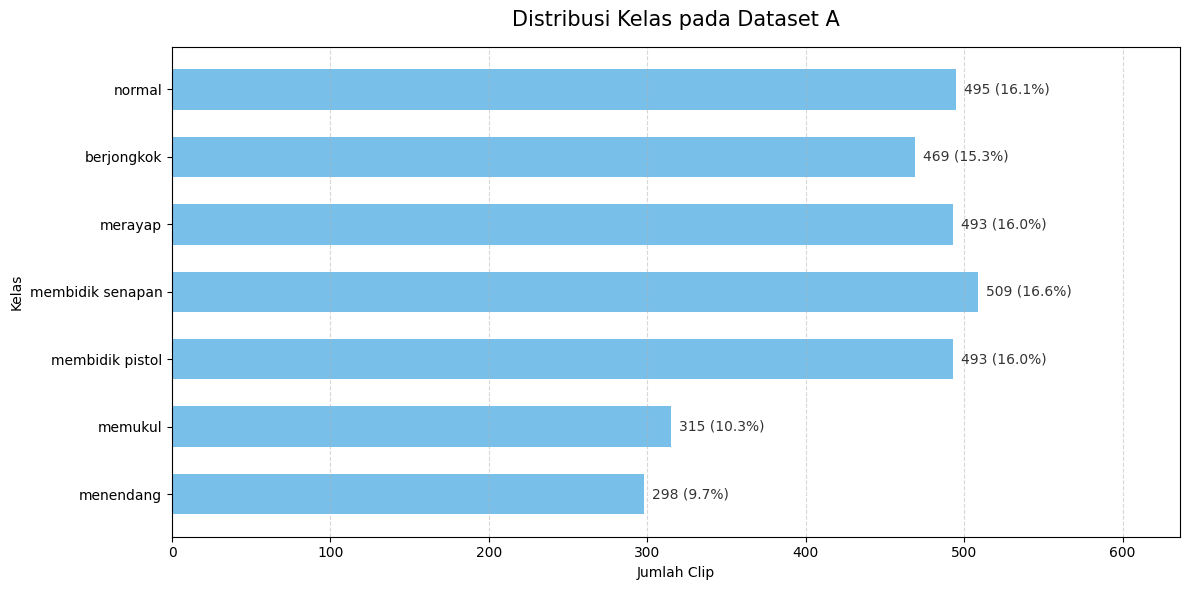

In [20]:
sorted_items = sorted(counter.items())
ids    = [item[0] for item in sorted_items]
counts = [item[1] for item in sorted_items]
names  = [stdet_label_map_id.get(label_id, f'kelas_{label_id}') for label_id in ids]
total  = len(labels)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(names, counts, color="#78C0EA", height=0.6)

# Tambah label nilai di ujung bar
for bar, count in zip(bars, counts):
    pct = count / total * 100
    ax.text(
        bar.get_width() + max(counts) * 0.01, 
        bar.get_y() + bar.get_height() / 2, 
        f'{count} ({pct:.1f}%)',
        va='center', ha='left', fontsize=10, color='#333333'
    )

ax.set_xlabel('Jumlah Clip', fontsize=10)
ax.set_ylabel('Kelas', fontsize=10)
#ax.set_title(f'Distribusi Kelas pada Dataset {os.path.basename(combined_pkl)}', fontsize=13, pad=15)
ax.set_title('Distribusi Kelas pada Dataset A', fontsize=15, pad=15)
ax.set_xlim(0, max(counts) * 1.25)  # beri ruang untuk label
ax.invert_yaxis()  # kelas dengan count terbesar di atas
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

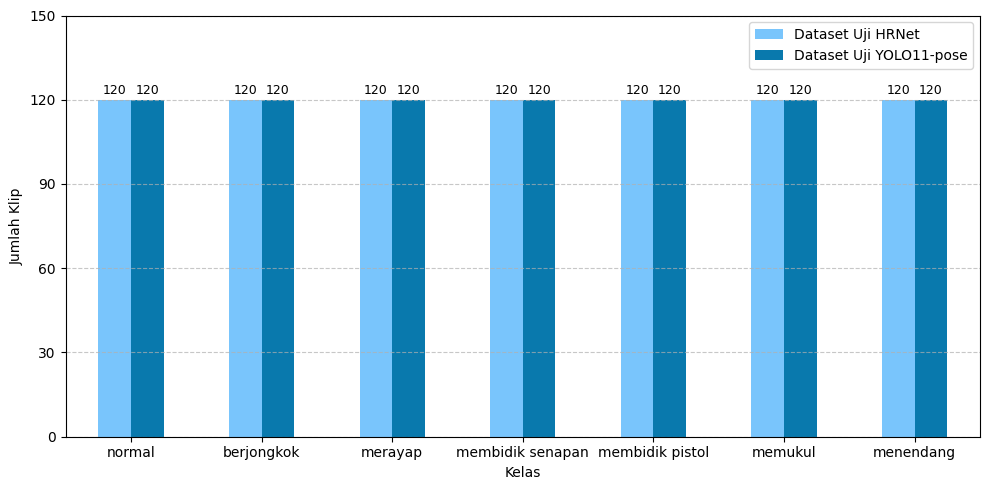

In [6]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# Load file PKL
with open('../ver2026/03_dataset/data_train/fin_new/ciis_26_test1x.pkl', 'rb') as f:
    data1 = pickle.load(f)

with open('../ver2026/03_dataset/data_train/fin_new/ciis_26_test2x.pkl', 'rb') as f:
    data2 = pickle.load(f)

label_map = {
    0: "normal",
    1: "berjongkok",
    2: "merayap",
    3: "membidik senapan",
    4: "membidik pistol",
    5: "memukul",
    6: "menendang"
}

# Ambil label dari annotations
labels1 = [x["label"] for x in data1["annotations"]]
labels2 = [x["label"] for x in data2["annotations"]]

# Hitung jumlah tiap label
count1 = pd.Series(labels1).value_counts().sort_index()
count2 = pd.Series(labels2).value_counts().sort_index()

# Gabungkan agar label yang tidak ada tetap muncul
df = pd.concat(
    [count1, count2],
    axis=1,
    keys=["Dataset Uji HRNet", "Dataset Uji YOLO11-pose"]
).fillna(0)

df.index = [label_map.get(i, str(i)) for i in df.index]

# Plot
ax = df.plot(
    kind="bar",
    figsize=(10, 5),
    #color=["#65C1F2", "#95CFA9"],
    color=["#79C5FC", "#0979AD"],
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=2,
        fontsize=9
    )

plt.ylim(0, 150)
plt.yticks(range(0, 151, 30))

# plt.title("Perbandingan Jumlah Sampel per Label")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Klip")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
csv_files = glob.glob('../ver2026/dataset/data_in/csv_pkl/**/*.csv', recursive=True)

print(f'Total file CSV ditemukan: {len(csv_files)}')
print()

all_labels = {}

for csv_path in csv_files:
    with open(csv_path) as f:
        rows = list(csv.reader(f))
    
    for row in rows:
        if not row or row[0] in ('none', 'annotate!', ''):
            continue
        label = row[0].strip()
        all_labels[label] = all_labels.get(label, 0) + 1

print('Label unik dari semua CSV:')
for label, count in sorted(all_labels.items()):
    match = label in stdet_label_map
    status = '✅' if match else '❌ tidak match label map'
    print(f'  "{label}" → {count} clip {status}')

Total file CSV ditemukan: 50

Label unik dari semua CSV:
  "berjongkok" → 132 clip ✅
  "membidik pistol" → 476 clip ✅
  "membidik senapan" → 280 clip ✅
  "memukul" → 39 clip ✅
  "menendang" → 20 clip ✅
  "merayap" → 360 clip ✅
  "normal" → 495 clip ✅
